Purpose of the Analysis

We want to check if the COVID-19 vaccine works.

We have two groups:

Vaccinated group: 10,000 people, 50 got COVID

Unvaccinated group: 10,000 people, 200 got COVID

From this, we calculate:

RR (Relative Risk)

VE (Vaccine Efficacy)

RD (Risk Difference)

Confidence intervals (CIs) for RR and RD

Hypothesis test (Chi-square)

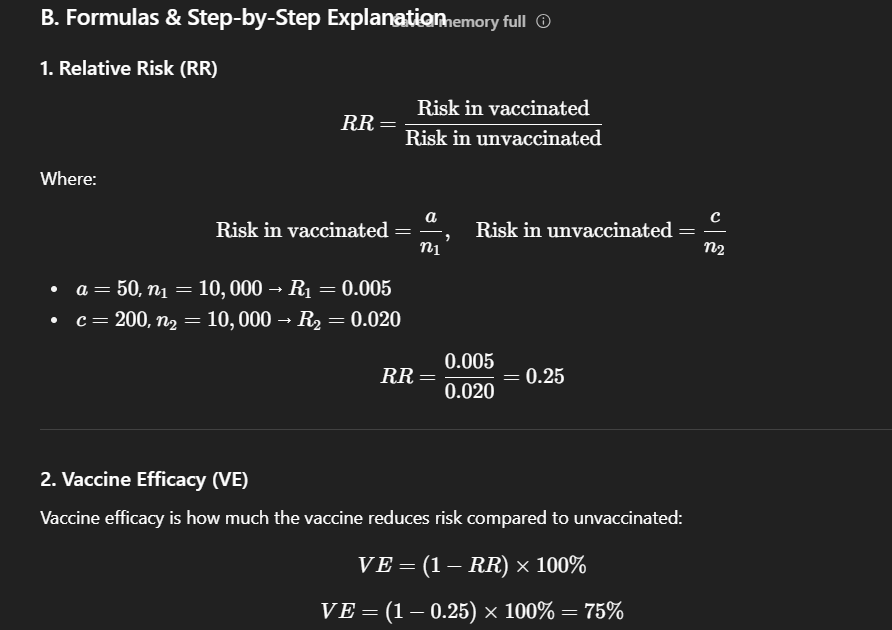

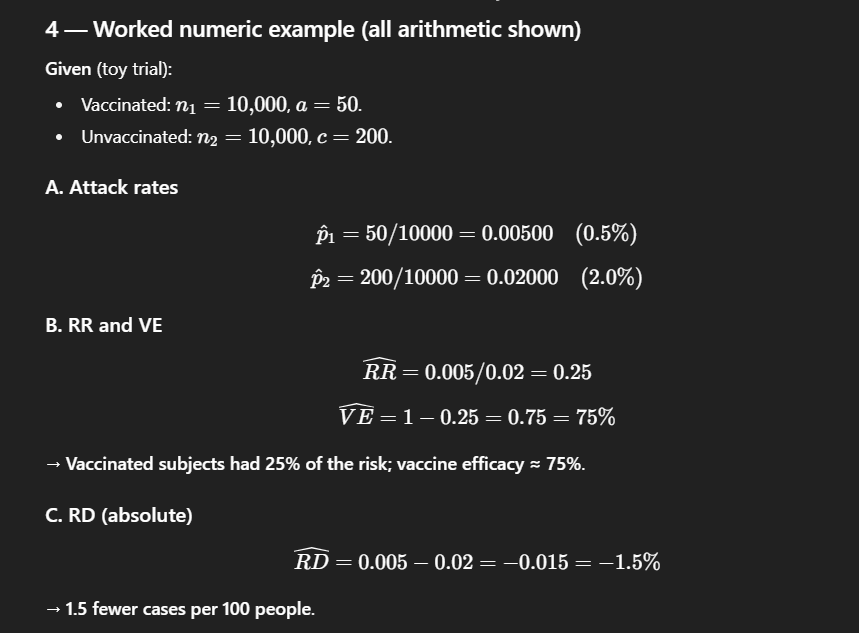

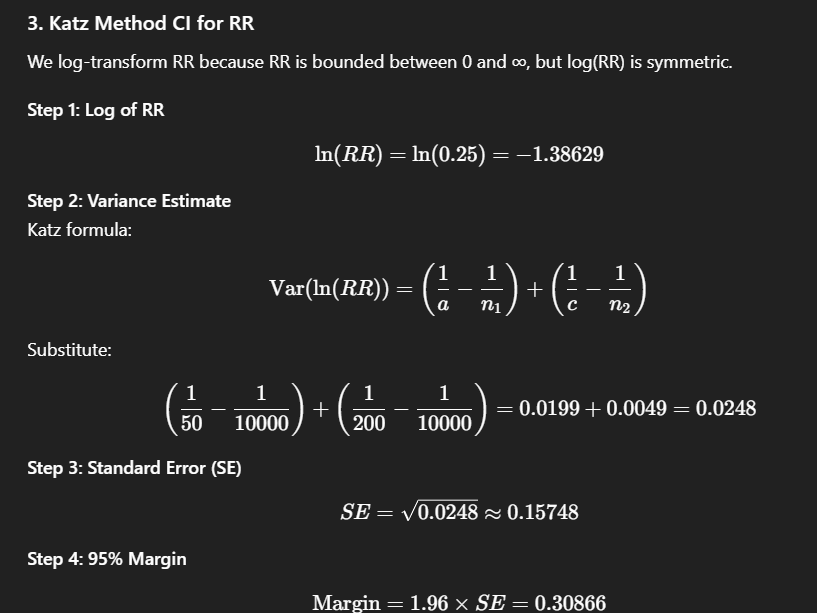

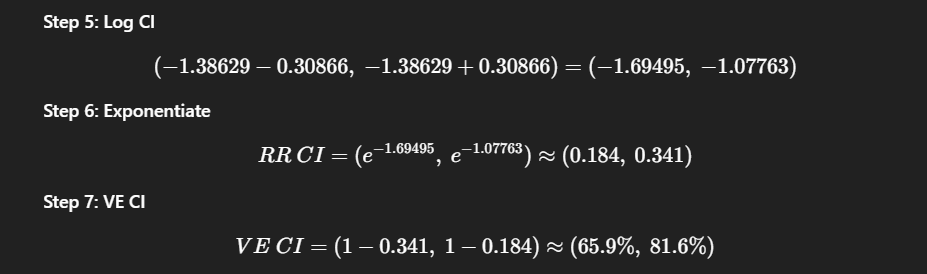

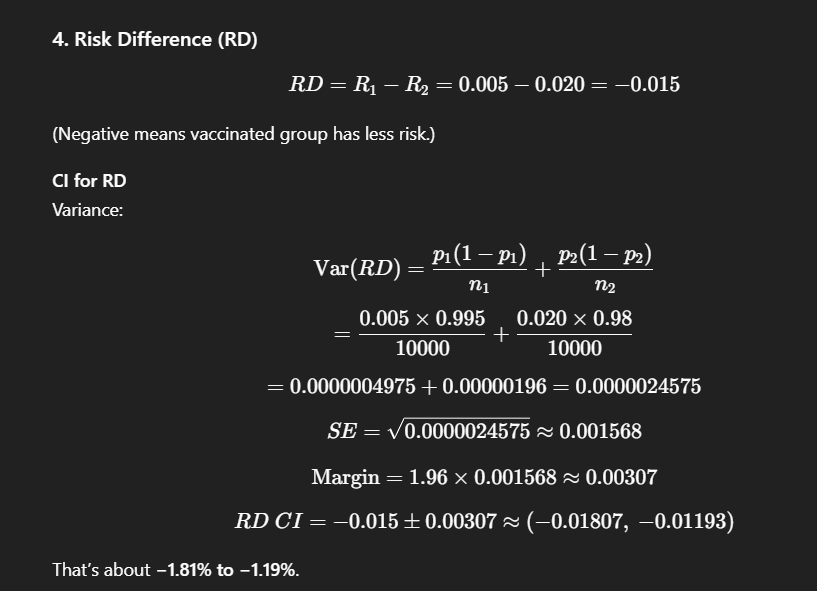

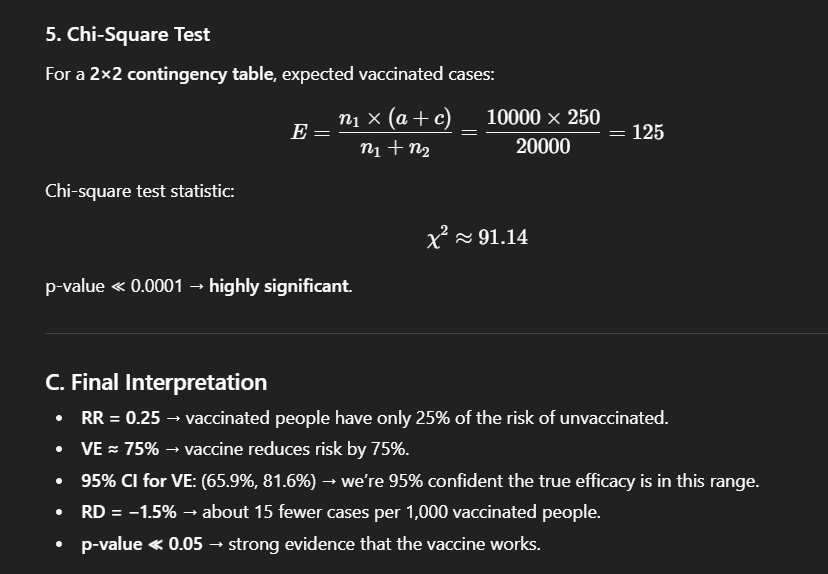

In [2]:
# Cell 1: create synthetic dataset (50 rows) and save CSV
import csv
import datetime

rows = []
start = datetime.datetime(2025, 8, 9, 10, 0, 0)  # starting timestamp
uid = 1


In [3]:
start

datetime.datetime(2025, 8, 9, 10, 0)

In [4]:

# We'll make 25 vaccinated (group 'V') and 25 unvaccinated (group 'C')
# Choose case counts to make the example non-trivial:
# vaccinated cases a = 2 (out of 25)
# unvaccinated cases c = 6 (out of 25)
a = 2
n1 = 25
c = 6
n2 = 25

# Vaccinated rows
for i in range(n1):
    ts = (start + datetime.timedelta(seconds=uid)).isoformat()
    converted = 1 if i < a else 0
    rows.append((uid, ts, 'V', 'vaccine_arm', converted))
    uid += 1

# Control rows
for i in range(n2):
    ts = (start + datetime.timedelta(seconds=uid)).isoformat()
    converted = 1 if i < c else 0
    rows.append((uid, ts, 'C', 'control_arm', converted))
    uid += 1



In [5]:
# Save CSV
with open('vaccine_50.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['user_id', 'timestamp', 'group', 'arm', 'case'])
    w.writerows(rows)

print("Created vaccine_50.csv with", len(rows), "rows")
print("Sample (first 8 rows):")
for r in rows[:8]:
    print(r)


Created vaccine_50.csv with 50 rows
Sample (first 8 rows):
(1, '2025-08-09T10:00:01', 'V', 'vaccine_arm', 1)
(2, '2025-08-09T10:00:02', 'V', 'vaccine_arm', 1)
(3, '2025-08-09T10:00:03', 'V', 'vaccine_arm', 0)
(4, '2025-08-09T10:00:04', 'V', 'vaccine_arm', 0)
(5, '2025-08-09T10:00:05', 'V', 'vaccine_arm', 0)
(6, '2025-08-09T10:00:06', 'V', 'vaccine_arm', 0)
(7, '2025-08-09T10:00:07', 'V', 'vaccine_arm', 0)
(8, '2025-08-09T10:00:08', 'V', 'vaccine_arm', 0)


In [6]:
# Cell 2: aggregate counts and compute attack rates (no external libs)
import math

# Summarize from rows created above
n1 = sum(1 for r in rows if r[2] == 'V')
a = sum(r[4] for r in rows if r[2] == 'V')
n2 = sum(1 for r in rows if r[2] == 'C')
c = sum(r[4] for r in rows if r[2] == 'C')


In [7]:

p1 = a / n1
p2 = c / n2


In [8]:

print("Vaccinated: n1 =", n1, ", cases a =", a, ", attack rate p1 = {:.5f}".format(p1))
print("Unvaccinated: n2 =", n2, ", cases c =", c, ", attack rate p2 = {:.5f}".format(p2))


Vaccinated: n1 = 25 , cases a = 2 , attack rate p1 = 0.08000
Unvaccinated: n2 = 25 , cases c = 6 , attack rate p2 = 0.24000


In [9]:
# Cell 3: RR and VE
RR = (p1 / p2) if p2 != 0 else float('inf')
VE = 1 - RR
print("Risk Ratio (RR) = {:.5f}".format(RR))
print("Vaccine Efficacy (VE) = {:.2%}".format(VE))


Risk Ratio (RR) = 0.33333
Vaccine Efficacy (VE) = 66.67%


In [10]:
# Cell 4: Katz CI for RR (requires a>0 and c>0)
import math

if a > 0 and c > 0:
    lnRR = math.log(RR)
    var_lnRR = (1.0/a - 1.0/n1) + (1.0/c - 1.0/n2)
    se_lnRR = math.sqrt(var_lnRR)
    z975 = 1.96
    ln_low = lnRR - z975 * se_lnRR
    ln_high = lnRR + z975 * se_lnRR
    RR_low = math.exp(ln_low)
    RR_high = math.exp(ln_high)
    VE_low = 1 - RR_high
    VE_high = 1 - RR_low

    print("ln(RR) = {:.6f}".format(lnRR))
    print("Var(lnRR) ≈ {:.6f}".format(var_lnRR))
    print("SE(lnRR) ≈ {:.6f}".format(se_lnRR))
    print("95% CI on log scale: ({:.6f}, {:.6f})".format(ln_low, ln_high))
    print("RR 95% CI ≈ ({:.5f}, {:.5f})".format(RR_low, RR_high))
    print("VE 95% CI ≈ ({:.2%}, {:.2%})".format(VE_low, VE_high))
else:
    print("Katz CI not available (a or c is zero).")


ln(RR) = -1.098612
Var(lnRR) ≈ 0.586667
SE(lnRR) ≈ 0.765942
95% CI on log scale: (-2.599858, 0.402633)
RR 95% CI ≈ (0.07428, 1.49576)
VE 95% CI ≈ (-49.58%, 92.57%)


In [11]:
# Cell 5: RD and Wald CI
import math
RD = p1 - p2
var_RD = (p1 * (1 - p1)) / n1 + (p2 * (1 - p2)) / n2
se_RD = math.sqrt(var_RD)
z975 = 1.96
rd_low = RD - z975 * se_RD
rd_high = RD + z975 * se_RD



In [12]:
print("Risk Difference (RD) = {:.5f} (i.e. {:.2%})".format(RD, RD))
print("SE(RD) ≈ {:.6f}".format(se_RD))
print("95% CI for RD ≈ ({:.5f}, {:.5f}) i.e. ({:.2%}, {:.2%})".format(rd_low, rd_high, rd_low, rd_high))


Risk Difference (RD) = -0.16000 (i.e. -16.00%)
SE(RD) ≈ 0.101193
95% CI for RD ≈ (-0.35834, 0.03834) i.e. (-35.83%, 3.83%)


In [13]:
# Cell 6: Chi-square (approx) and Fisher exact (exact two-sided p)
import math

# Observed counts
O_vac_cases = a
O_vac_nocases = n1 - a
O_ctrl_cases = c
O_ctrl_nocases = n2 - c

total_cases = a + c
N = n1 + n2

# Expected under H0
E_vac_cases = n1 * total_cases / N
E_vac_nocases = n1 - E_vac_cases
E_ctrl_cases = n2 * total_cases / N
E_ctrl_nocases = n2 - E_ctrl_cases



In [14]:
chi2 = 0.0
for O, E in [(O_vac_cases, E_vac_cases), (O_vac_nocases, E_vac_nocases),
             (O_ctrl_cases, E_ctrl_cases), (O_ctrl_nocases, E_ctrl_nocases)]:
    if E > 0:
        chi2 += (O - E) ** 2 / E



In [15]:
# approximate two-sided p using relation with normal for df=1:
def normal_cdf(z):
    return 0.5 * (1 + math.erf(z / math.sqrt(2)))



In [16]:
z_equiv = math.sqrt(chi2)
p_chi2_two = 2 * (1 - normal_cdf(z_equiv))

print("Chi-square ≈ {:.5f}, approx two-sided p ≈ {:.6g}".format(chi2, p_chi2_two))



Chi-square ≈ 2.38095, approx two-sided p ≈ 0.122823


In [17]:
# Fisher exact two-sided p (hypergeometric)
# P(X=a_obs) = C(n1, a_obs) * C(n2, total_cases - a_obs) / C(N, total_cases)
from math import comb

def fisher_two_sided(a_obs, n1, total_cases, n2):
    total = n1 + n2
    # probability of observed table
    p_obs = comb(n1, a_obs) * comb(n2, total_cases - a_obs) / comb(total, total_cases)
    # sum probs of tables with probability <= p_obs
    p_sum = 0.0
    min_a = max(0, total_cases - n2)
    max_a = min(total_cases, n1)
    for a_prime in range(min_a, max_a + 1):
        p_tmp = comb(n1, a_prime) * comb(n2, total_cases - a_prime) / comb(total, total_cases)
        if p_tmp <= p_obs + 1e-15:
            p_sum += p_tmp
    return p_obs, p_sum

p_obs, p_fisher_two = fisher_two_sided(a, n1, total_cases, n2)
print("Fisher exact (two-sided) p ≈ {:.6g} (prob of observed table = {:.6g})".format(p_fisher_two, p_obs))


Fisher exact (two-sided) p ≈ 0.246719 (prob of observed table = 0.0989609)


In [18]:
# Cell 7: summary
print("===== SUMMARY =====")
print("Vaccinated: n1 = {}, cases = {}, rate = {:.3%}".format(n1, a, p1))
print("Unvaccinated: n2 = {}, cases = {}, rate = {:.3%}".format(n2, c, p2))
print("RR = {:.4f} (RR<1 means vaccine lowers risk)".format(RR))
print("VE = {:.2%} (1 - RR)".format(VE))
print("RR 95% CI ≈ ({:.4f}, {:.4f})".format(RR_low, RR_high) if a>0 and c>0 else "RR CI not available")
print("RD = {:.4f} ({:.2%}), 95% CI ≈ ({:.4f}, {:.4f})".format(RD, RD, rd_low, rd_high))
print("Chi-square ≈ {:.4f}, approx two-sided p ≈ {:.6g}".format(chi2, p_chi2_two))
print("Fisher exact two-sided p ≈ {:.6g}".format(p_fisher_two))


===== SUMMARY =====
Vaccinated: n1 = 25, cases = 2, rate = 8.000%
Unvaccinated: n2 = 25, cases = 6, rate = 24.000%
RR = 0.3333 (RR<1 means vaccine lowers risk)
VE = 66.67% (1 - RR)
RR 95% CI ≈ (0.0743, 1.4958)
RD = -0.1600 (-16.00%), 95% CI ≈ (-0.3583, 0.0383)
Chi-square ≈ 2.3810, approx two-sided p ≈ 0.122823
Fisher exact two-sided p ≈ 0.246719


In [19]:
if p_fisher_two < 0.05:
    print("Decision (Fisher): reject H0 -> evidence vaccine changes risk")
else:
    print("Decision (Fisher): fail to reject H0 -> not enough evidence (at 5%)")


Decision (Fisher): fail to reject H0 -> not enough evidence (at 5%)
